In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [3]:
data_transformer = transforms.ToTensor()

In [4]:
embedding_size = 128
to_decoder_dim = 64
mask_ratio = 0.75
num_attn_heads = 4
num_of_hidden_nodes = 2048
num_of_encoder_blocks = 8
num_of_decoder_blocks = 4
input_size = 32
patch_size = 2
batch_size = 64

In [5]:
train_dataset = datasets.CIFAR10(
    root = './data',
    train = True,
    download = True, 
    transform = data_transformer

)

val_dataset = datasets.CIFAR10(
    root = './data',
    train = False,
    download = True, 
    transform = data_transformer

)

In [6]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)

In [7]:
print(train_dataset.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [8]:
images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([64, 3, 32, 32])


In [9]:
images[0][1][3]

tensor([0.4627, 0.3725, 0.5137, 0.6196, 0.6588, 0.6196, 0.5490, 0.6588, 0.5843,
        0.5176, 0.5882, 0.6118, 0.4118, 0.4118, 0.4863, 0.3961, 0.2824, 0.5647,
        0.7647, 0.7529, 0.6667, 0.6902, 0.7333, 0.7216, 0.5686, 0.3059, 0.1216,
        0.1725, 0.4588, 0.4745, 0.5294, 0.5686])

In [10]:
#converting the images into patches
patches = F.unfold(images, kernel_size=2, stride=2)
print("before transpose",patches.shape) #before transpose
patches = patches.transpose(1,2)
print("before transpose",patches.shape) #after transpose
#before patch creation - (64,3,32,32)
#Output (after transpose) - (64,256,12) 64 - batch, 256 patches (as 32/2 = 16 --> 16x16=256) , 12 flattened vector got by - 2x2-->4x3 = 12
# all channel values are flattened 

before transpose torch.Size([64, 12, 256])
before transpose torch.Size([64, 256, 12])


In [11]:
#embedding the patches to increase information representation
embedder = nn.Linear(12, embedding_size)
patches = embedder(patches)
print(patches.shape)
# (B, P, C)
#B- batches, P - Patches,  C - dim/channels (got flatten up)

torch.Size([64, 256, 128])


In [12]:
#defining learnable position embeddings and adding them
pos_embed = nn.Parameter(torch.randn(1,256,128))
patches = patches + pos_embed
print(patches.shape)

torch.Size([64, 256, 128])


In [13]:
num_patches = patches.shape[1]

In [14]:
perm_nums = torch.randperm(num_patches)
print(perm_nums)

tensor([ 88,  15, 117, 149, 172, 255,  70, 226,  79, 180, 186, 102,   1,  16,
         81, 230, 183,  45,  39,  57, 246, 238, 231, 164,  35,  50, 142,   7,
        223, 212,  66, 194,  22,  49,  60, 131, 151, 110, 154,  82,   6,  27,
         28, 166,  85, 168, 101, 175, 128, 126, 171,  51, 187,  36, 218,  80,
        145,  61, 158, 123,  31, 193,  69, 198, 135,  25, 236,  58, 109, 169,
        161, 104, 159, 153, 112,  72,  32, 178, 208,  97,  64,  74, 174, 235,
         99,  77,  44, 134, 146, 105,  89, 152, 205,  23, 176,  68, 244,  18,
        162, 195, 239, 100, 206, 215, 185,  91, 177, 136,   8, 132,  43, 192,
         55,  56, 148, 243,  24,  48,   4,  20,  86,  14,  75, 118,  41, 115,
        229, 157,  10,   0,  73, 107,   5,  12,  78, 251,   9, 141,  21,  37,
        155, 219, 144, 165, 211, 127,  90,   3, 179, 202,  26, 253, 216,  34,
         40, 199,  33, 106,  93,  87,  65,  59, 129,  67,  53, 150, 232, 221,
         63,  98, 210,  30,  38, 184, 116, 233, 124, 250, 189, 1

In [15]:
mask_idx_count = int(num_patches*mask_ratio)
visible_idx_count = num_patches - mask_idx_count
print("patches selected for masking : ", mask_idx_count)
print("Patches unselected from masking : ", visible_idx_count)

patches selected for masking :  192
Patches unselected from masking :  64


In [16]:
mask_idxs = perm_nums[:mask_idx_count]
visible_idxs = perm_nums[mask_idx_count:]

print(mask_idxs)
print(visible_idxs)

tensor([ 88,  15, 117, 149, 172, 255,  70, 226,  79, 180, 186, 102,   1,  16,
         81, 230, 183,  45,  39,  57, 246, 238, 231, 164,  35,  50, 142,   7,
        223, 212,  66, 194,  22,  49,  60, 131, 151, 110, 154,  82,   6,  27,
         28, 166,  85, 168, 101, 175, 128, 126, 171,  51, 187,  36, 218,  80,
        145,  61, 158, 123,  31, 193,  69, 198, 135,  25, 236,  58, 109, 169,
        161, 104, 159, 153, 112,  72,  32, 178, 208,  97,  64,  74, 174, 235,
         99,  77,  44, 134, 146, 105,  89, 152, 205,  23, 176,  68, 244,  18,
        162, 195, 239, 100, 206, 215, 185,  91, 177, 136,   8, 132,  43, 192,
         55,  56, 148, 243,  24,  48,   4,  20,  86,  14,  75, 118,  41, 115,
        229, 157,  10,   0,  73, 107,   5,  12,  78, 251,   9, 141,  21,  37,
        155, 219, 144, 165, 211, 127,  90,   3, 179, 202,  26, 253, 216,  34,
         40, 199,  33, 106,  93,  87,  65,  59, 129,  67,  53, 150, 232, 221,
         63,  98, 210,  30,  38, 184, 116, 233, 124, 250, 189, 1

In [17]:
masked_patches = patches[:, mask_idxs , :]
visible_patches = patches[:, visible_idxs, :]

print(masked_patches.shape)
print(visible_patches.shape)

torch.Size([64, 192, 128])
torch.Size([64, 64, 128])


In [ ]:
class Patchify(nn.Module):
    def __init__(self):
        super().__init__()
     
     #this class actually converts the given input into patches, 
     #kernel = 2, stride = 2 there fore given the 32x32 image, each image will be converted to 32/2 = 16-> 16x16 patches = 256 patches in total 
        

    def forward(self,x):
        patches = F.unfold(x, kernel_size=2, stride=2) #used to create patches
        patches = patches.transpose(-1,-2) #transposing because this returns (B, C, P) (B-Batch, C-flattened CHannels /Dimension, P - patches) but we want (B,P,C)
        return patches


In [ ]:
class Embed_patches_add_pos(nn.Module):
    def __init__(self, embedding_size, no_of_patches):
        super().__init__()

        #This class embeds the patches and then adds position information of the tokens
        #we are not using Embedding class directly from torch because it will lead to look_up tables just like in NLP which we dont require
        #so using a linear layer that would project the existing dimensions (2x2x3 = 12) to desired dimensions
        self.embedding_dim = embedding_size
     
        self.no_of_patches = no_of_patches
        self.embedder = nn.Linear(12, self.embedding_dim)

        #we are creating position embeddings, 
        #position embeddings are learnable parameters
        #the index is the position, position is not learnt, it is fixed
        #but the vector representation of these positions is learnt  
        self.pos_embed = nn.Parameter(torch.randn(1,self.no_of_patches,self.embedding_dim))


    def forward(self,x):
        patchx = self.embedder(x)
        patchx = patchx + self.pos_embed

        return patchx



In [ ]:
class Mask(nn.Module):
    def __init__(self, num_patches, mask_ratio):
        super().__init__()
        self.num_patches = num_patches
        self.mask_ratio = mask_ratio

        #creating randum permutation of numbers to mask the patches randomly but following uniform distribution
        self.perm_nums = torch.randperm(num_patches)

    def forward(self, patches):
        mask_idx_count = int(self.num_patches*self.mask_ratio)
        visible_idx_count = self.num_patches - mask_idx_count
        mask_idxs = self.perm_nums[:mask_idx_count]
        visible_idxs = self.perm_nums[mask_idx_count:]
        masked_patches = patches[:, mask_idxs , :]
        visible_patches = patches[:, visible_idxs, :]

        return visible_patches, mask_idxs, self.perm_nums
        



In [21]:
#MultiHeadAttention
class MultiHeadAttention(nn.Module):
    def __init__(self, embedding_dim,num_patches,num_heads  ):
        super().__init__()
        #definitions
        #input and #output projections
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.num_patches = num_patches
        self.dim_per_head = self.embedding_dim//self.num_heads

        self.q = nn.Linear(self.embedding_dim, self.embedding_dim)
        self.k = nn.Linear(self.embedding_dim, self.embedding_dim)
        self.v = nn.Linear(self.embedding_dim, self.embedding_dim)
        
        self.proj = nn.Linear(self.embedding_dim, self.embedding_dim)

        #we need to divide the dotproduct with sqroot(dim_per_head) as scalars of dot product
        #increase as vector increases, and that leads to softmax being too peaky, meaning
        #softmax gives maximum attention/value to the bigger values so eventually smaller values are not given much of importance
        #so occurs vanishing gradient problem
        #variance of dot-product grow proportionally to dimension, 
        self.scale =self.dim_per_head**(-0.5)

    def split_heads(self, x):
        batch_sizee , seq_len, emb_dim = x.shape
        x = x.view(batch_sizee, seq_len, self.num_heads, self.dim_per_head )
        return x.permute(0,2,1,3)
    

    def merge_heads(self,x):  
        x = x.permute(0,2,1,3).contiguous()
        batch_sizee , seq_len, num_headss, dim_per_headd = x.shape
        return x.view(batch_sizee, seq_len, self.embedding_dim)

    def forward(self,x):
        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        #K = (64,4,256,32)
        #Q = (64,4,256,32)
        #K.T = (64, 4,32,256)
        #Q@K.T = (64,4, 256, 256)
        self.wei = Q@K.transpose(-1,-2)
        self.wei = self.wei * self.scale
        attn = F.softmax(self.wei, dim = -1)
        self.attn_map = attn
        self.output = attn@V

        self.output = self.merge_heads(self.output)
        return self.proj(self.output)

In [ ]:
class MLP(nn.Module):
    def __init__(self, embedding_dim, num_hidden_nodes, dropout=0.1):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_hidden_nodes = num_hidden_nodes
        self.fc1 = nn.Linear(self.embedding_dim, self.num_hidden_nodes)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(self.num_hidden_nodes, self.embedding_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

#MLP is just a part of the Encoder and Decoder architecture to just make the vector representation even more rich by just projecting them into higher dimensions

In [ ]:
class EncoderBlock(nn.Module):
    def __init__(self, embedding_dim , num_patches, num_attn_heads, num_of_hidden_nodes):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_patches = num_patches
        self.num_attn_heads = num_attn_heads
        self.num_hidden_nodes = num_of_hidden_nodes

        self.norm1 = nn.LayerNorm(self.embedding_dim)
        self.norm2 = nn.LayerNorm(self.embedding_dim)

        self.attention = MultiHeadAttention(self.embedding_dim, self.num_patches, self.num_attn_heads)
        self.mlp = MLP(self.embedding_dim, self.num_hidden_nodes, dropout=0.25)

    def forward(self, x):
        residual1 = x
        x = self.norm1(x)
        attn_opt = self.attention(x)
        attn_opt = attn_opt + residual1

        residual2 = attn_opt
        x = self.norm2(attn_opt)
        mlp_opt = self.mlp(x)
        mlp_opt = mlp_opt+residual2

        return mlp_opt
    
    #Encoder block is simple and follos the same architecture given in "Attention is all you need" paper


In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, to_decoder_dim , num_patches, num_attn_heads, num_of_hidden_nodes):
        super().__init__()
        self.to_decoder_dim = to_decoder_dim
        self.num_patches = num_patches
        self.num_attn_heads = num_attn_heads
        self.num_hidden_nodes = num_of_hidden_nodes

        self.norm1 = nn.LayerNorm(self.to_decoder_dim)
        self.norm2 = nn.LayerNorm(self.to_decoder_dim)

        self.attention = MultiHeadAttention(self.to_decoder_dim, self.num_patches, self.num_attn_heads)
        self.mlp = MLP(self.to_decoder_dim, self.num_hidden_nodes, dropout=0.25)

    def forward(self, x):
        residual1 = x
        x = self.norm1(x)
        attn_opt = self.attention(x)
        attn_opt = attn_opt + residual1

        residual2 = attn_opt
        x = self.norm2(attn_opt)
        mlp_opt = self.mlp(x)
        mlp_opt = mlp_opt+residual2

        return mlp_opt
        
#We are not using cross attention in this decoder like in Attention is all you need, it is not required 
#as according to MAE paper, encoder only sees visible patches , decoder would see both visible and masked patches, so no cross attention which would indirectly inject information into decoder from encoder
#Decoder follows the exact same architecture as of Encoder
#Because the objective of MAE is to keep Decoder light as much as possible

In [ ]:
#This is the main class which integrates each and every step out there

class MAE(nn.Module):
    def __init__(self, batch_size,input_size, patch_size,mask_ratio, embedding_dim , num_attn_heads, num_of_hidden_nodes,num_of_encoder_blocks,num_of_decoder_blocks,to_decoder_dim ):
        super().__init__()
        
        self.batch_size = batch_size
        self.input_size = input_size
        self.patch_size = patch_size
        self.embedding_dim = embedding_dim
        self.num_patches = (self.input_size // self.patch_size)**2
        self.num_attn_heads = num_attn_heads
        self.num_of_hidden_nodes = num_of_hidden_nodes
        self.num_of_encoder_blocks = num_of_encoder_blocks
        self.num_of_decoder_blocks = num_of_decoder_blocks
        self.to_decoder_dim = to_decoder_dim
        self.mask_ratio = mask_ratio
        self.num_of_masked = int(self.num_patches*self.mask_ratio)

        self.layer_to_dec_dim = nn.Linear(self.embedding_dim, self.to_decoder_dim)
        self.mask_tokens = nn.Parameter(torch.randn(1, 1, self.to_decoder_dim))
        self.to_original_dim = nn.Linear(self.to_decoder_dim, 12)

        self.patching = Patchify()
        self.emb_posemb = Embed_patches_add_pos(self.embedding_dim,self.num_patches)
        self.masking = Mask(self.num_patches, self.mask_ratio)

        self.encoder = nn.Sequential(*[
            EncoderBlock(self.embedding_dim, self.num_patches, self.num_attn_heads, self.num_of_hidden_nodes)
            for _ in range(self.num_of_encoder_blocks)
        ])   #the following has been done, inorder to repeat the encoder self.num_of_encoder_blocks time, so that model can understand representations and symantics better
        #these are not run parallelly, but run sequentially one after the another,so when x goes in and latent comes out, the latent is again fed into encoder in that particular epoch
        
        self.decoder = nn.Sequential(*[
            DecoderBlock(self.to_decoder_dim, self.num_patches, self.num_attn_heads, self.num_of_hidden_nodes)
            for _ in range(self.num_of_decoder_blocks)  
        ])
        #the above description is applicable for decoder as well



    def forward(self,x):
        raw_patches = self.patching(x)   #creating patches
        patches = self.emb_posemb(raw_patches) #embedding the patches and adding position embeddings
        visible_patches , mask_idxs , perm_nums = self.masking(patches) #masking the patches, which returns visible patches for encoder, ids of masked patches required to collect these later
                                                                        #per_nums for applying inverted permutation inorder to restore the order of masked and unmasked patches collectively
        mask_idxs = mask_idxs.long()  #indexes needs to be in long format to get processed (It was a bug, bcz initially it was in int )

        latent = self.encoder(visible_patches) #output from encoder
        latent = self.layer_to_dec_dim(latent) #reducing the dimension inorder to send inot decoder

        # print("SHape of latent" , latent.shape)  #print statements were used for debugging purpose
        # print("Shape of mask_tokens" , mask_tokens.shape)

        B = latent.shape[0]  #Note: A lesson I learnt!! dont hardcode batchsize in your pipeline, make sure to keep it dynamic as much , wherever as possible
        mask_tokens = self.mask_tokens.repeat(B, self.num_of_masked, 1) #created the mask_tokens with (1,1,dim) but we need it (64,num_of_masked, dim) so using repeat to repeat the same masked tokens accross the batches to keep them consistent
        all_tokens =  torch.cat([latent, mask_tokens], dim=1) #concatinate the masked and visible tokens to send them into decoder
        restored = all_tokens[:,torch.argsort(perm_nums), :] #restore the random order before sending them to into decoder


        decoder_opt = self.decoder(restored)   #output from decoder
        pred_pixels = self.to_original_dim(decoder_opt) #no we need to convert the dim to 12 (original) to compare and calculate the losses

        #expectation of Fold : (B, C*k*k, L)
        #so transpose as our original shape of pred_pixels is : (B, L , C*K*K)
        pred_masked = pred_pixels[:, mask_idxs]
        pred_pixels = pred_pixels.transpose(-1,-2)
        reconstructed = F.fold(pred_pixels, (32,32), kernel_size=2, stride=2)


        # print(mask_idxs.min())
        # print(mask_idxs.max())
        # print(raw_patches.shape)
        # print(mask_idxs.shape)

        # print(mask_idxs.device)
        # print(raw_patches.device)

        # print(mask_idxs.dtype)

        target_masked = raw_patches[:, mask_idxs]

        loss = F.mse_loss(pred_masked, target_masked) #MSE loss is being used
   
        return reconstructed, loss





        

        


In [26]:
model = MAE(
    batch_size=batch_size,
    embedding_dim=embedding_size,
    patch_size=patch_size,
    mask_ratio=mask_ratio,
    input_size=input_size,
    num_attn_heads=num_attn_heads,
    num_of_hidden_nodes=num_of_hidden_nodes,
    num_of_encoder_blocks=num_of_encoder_blocks,
    num_of_decoder_blocks=num_of_decoder_blocks,
    to_decoder_dim=to_decoder_dim
)

In [27]:
criterion = nn.MSELoss()

In [28]:
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-5)


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [30]:
model = model.to(device=device)

In [31]:
from torchinfo import summary
print(summary(model))

Layer (type:depth-idx)                   Param #
MAE                                      64
├─Linear: 1-1                            8,256
├─Linear: 1-2                            780
├─Patchify: 1-3                          --
├─Embed_patches_add_pos: 1-4             32,768
│    └─Linear: 2-1                       1,664
├─Mask: 1-5                              --
├─Sequential: 1-6                        --
│    └─EncoderBlock: 2-2                 --
│    │    └─LayerNorm: 3-1               256
│    │    └─LayerNorm: 3-2               256
│    │    └─MultiHeadAttention: 3-3      66,048
│    │    └─MLP: 3-4                     526,464
│    └─EncoderBlock: 2-3                 --
│    │    └─LayerNorm: 3-5               256
│    │    └─LayerNorm: 3-6               256
│    │    └─MultiHeadAttention: 3-7      66,048
│    │    └─MLP: 3-8                     526,464
│    └─EncoderBlock: 2-4                 --
│    │    └─LayerNorm: 3-9               256
│    │    └─LayerNorm: 3-10          

In [32]:
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0


    for images,labels in train_loader:
        images = images.to(device)

        
        optimizer.zero_grad()
        _, loss = model(images)
        loss.backward()
        optimizer.step()
        total_loss +=loss.item()
        
        

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.0797180028589409
Epoch 2, Loss: 0.05345383395567117
Epoch 3, Loss: 0.04847466568355365
Epoch 4, Loss: 0.04598106025620494
Epoch 5, Loss: 0.04221197782212968


In [33]:
model.eval()

val_loss = 0

with torch.no_grad():

    for images, _ in val_loader:

        images = images.to(device)

        _, loss = model(images)

        val_loss += loss.item()

val_loss /= len(val_loader)

print("Validation Loss:", val_loss)

Validation Loss: 0.03816318979403775


In [34]:
model.eval()

with torch.no_grad():

    images, _ = next(iter(val_loader))

    images = images.to(device)

    reconstructed, _ = model(images)

In [35]:
orig = images[0].permute(1,2,0).cpu()
recon = reconstructed[0].permute(1,2,0).cpu()

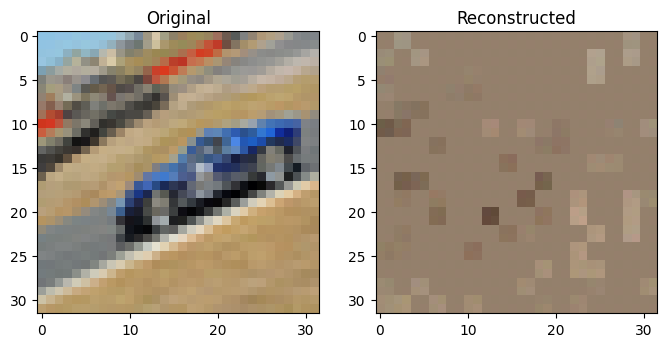

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(orig)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(recon)
plt.title("Reconstructed")

plt.show()